# 05 · Modelling — comparación de algoritmos

Entrenamos y comparamos **cuatro clasificadores** sobre el set de features
seleccionado (`churn_dataset_features.csv`):

| Modelo | Tipo |
|---|---|
| **Random Forest** | bagging de árboles (baseline de los papers) |
| **XGBoost** | gradient boosting |
| **LightGBM** | gradient boosting (histogram-based) |
| **CatBoost** | gradient boosting (ordered boosting) |

## Manejo del desbalance (sin resampling)

Siguiendo los papers (Gattermann-Itschert & Thonemann), **no** usamos under/over-
sampling — eso cambia el tamaño de muestra que el multi-slicing busca aprovechar.
Usamos **aprendizaje sensible al costo**:
- RF / LightGBM: `class_weight='balanced'`
- XGBoost: `scale_pos_weight = neg/pos`
- CatBoost: `auto_class_weights='Balanced'`

## Evaluación: los dos protocolos

Cada modelo se evalúa con **GroupKFold por vendedora** (generalización honesta) y
con el **split OOT** (producción). Hiperparámetros modestos y comparables; el
tuning fino va en un paso posterior.


## 0 · Setup, datos y split

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             precision_score, recall_score, f1_score)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

base = Path.cwd()
while not (base / "data" / "processed").exists() and base != base.parent:
    base = base.parent
df = pd.read_csv(base / "data" / "processed" / "churn_dataset_features.csv", parse_dates=["mes_obs"])
ID = ["id_vendedor", "mes_obs", "mes_rank"]; TARGET = "churn"
FEATS = [c for c in df.columns if c not in ID + [TARGET]]
X = df[FEATS]; y = df[TARGET].values; groups = df["id_vendedor"].values
print(f"dataset: {df.shape[0]:,} filas | {len(FEATS)} features | prevalencia churn {y.mean():.3f}")


def oot_split(df, v=6, test_months=4, rank_col="mes_rank"):
    rank = df[rank_col]
    test_start = rank.max() - test_months + 1
    train_last = test_start - 1 - v
    return (rank <= train_last).values, (rank >= test_start).values


train_mask, test_mask = oot_split(df)
spw = (y[train_mask] == 0).sum() / (y[train_mask] == 1).sum()   # scale_pos_weight para XGB
print(f"train {train_mask.sum():,} | test {test_mask.sum():,} | scale_pos_weight={spw:.2f}")

dataset: 30,356 filas | 68 features | prevalencia churn 0.309
train 28,311 | test 803 | scale_pos_weight=2.22


## 1 · Definición de los modelos (desbalance vía pesos)

In [2]:
def make_models():
    return {
        "RandomForest": RandomForestClassifier(
            n_estimators=400, max_depth=8, class_weight="balanced",
            n_jobs=-1, random_state=42),
        "XGBoost": XGBClassifier(
            n_estimators=400, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, scale_pos_weight=spw,
            eval_metric="logloss", tree_method="hist", n_jobs=-1, random_state=42),
        "LightGBM": LGBMClassifier(
            n_estimators=400, num_leaves=31, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, class_weight="balanced",
            n_jobs=-1, random_state=42, verbose=-1),
        "CatBoost": CatBoostClassifier(
            iterations=400, depth=4, learning_rate=0.05,
            auto_class_weights="Balanced", random_seed=42, verbose=0),
    }

print("Modelos:", list(make_models().keys()))

Modelos: ['RandomForest', 'XGBoost', 'LightGBM', 'CatBoost']


## 2 · Evaluación con los dos protocolos

Para cada modelo:
- **GroupKFold (5)**: predicciones out-of-fold → AUC, PR-AUC, lift del decil top.
- **OOT**: fit en train, predecir test → AUC (+ std por mes), F1/precision/recall
  a t=0.5, lift del decil top.


In [3]:
def top_decile_lift(yt, p):
    k = max(len(yt) // 10, 1)
    sel = np.argsort(-p)[:k]
    return yt[sel].mean() / yt.mean()

def eval_model(name, model):
    # --- GroupKFold ---
    oof = cross_val_predict(model, X, y, cv=GroupKFold(5), groups=groups,
                            method="predict_proba", n_jobs=None)[:, 1]
    g_auc = roc_auc_score(y, oof); g_ap = average_precision_score(y, oof)
    g_lift = top_decile_lift(y, oof)
    # --- OOT ---
    m = model; m.fit(X[train_mask], y[train_mask])
    p = m.predict_proba(X[test_mask])[:, 1]; yt = y[test_mask]
    pr = (p >= 0.5).astype(int)
    o_auc = roc_auc_score(yt, p)
    # std de AUC por mes del test
    dft = df[test_mask].copy(); dft["p"] = p
    aucs = [roc_auc_score(g["churn"], g["p"]) for _, g in
            dft.groupby(dft["mes_obs"].dt.strftime("%Y-%m")) if g["churn"].nunique() > 1]
    return {
        "gkf_AUC": g_auc, "gkf_PRAUC": g_ap, "gkf_lift10": g_lift,
        "oot_AUC": o_auc, "oot_AUCstd": np.std(aucs),
        "oot_F1": f1_score(yt, pr, zero_division=0),
        "oot_prec": precision_score(yt, pr, zero_division=0),
        "oot_rec": recall_score(yt, pr),
        "oot_lift10": top_decile_lift(yt, p),
    }

rows = {}
for name, model in make_models().items():
    print(f"evaluando {name} ...")
    rows[name] = eval_model(name, model)
res = pd.DataFrame(rows).T
print("\nlisto")

evaluando RandomForest ...


evaluando XGBoost ...


evaluando LightGBM ...


evaluando CatBoost ...



listo


## 3 · Comparación

In [4]:
cols = ["gkf_AUC", "gkf_PRAUC", "gkf_lift10", "oot_AUC", "oot_AUCstd",
        "oot_F1", "oot_prec", "oot_rec", "oot_lift10"]
tabla = res[cols].sort_values("oot_AUC", ascending=False)
print(tabla.round(4).to_string())

best = tabla["oot_AUC"].idxmax()
best_gkf = tabla["gkf_AUC"].idxmax()
print(f"\nMejor por AUC OOT:       {best} ({tabla.loc[best,'oot_AUC']:.4f})")
print(f"Mejor por AUC GroupKFold: {best_gkf} ({tabla.loc[best_gkf,'gkf_AUC']:.4f})")

              gkf_AUC  gkf_PRAUC  gkf_lift10  oot_AUC  oot_AUCstd  oot_F1  oot_prec  oot_rec  oot_lift10
CatBoost       0.7441     0.5324      2.0040   0.7649      0.0162  0.5470    0.4267   0.7619      2.2943
RandomForest   0.7418     0.5294      2.0072   0.7627      0.0233  0.5509    0.4361   0.7476      2.4377
LightGBM       0.7355     0.5229      1.9870   0.7566      0.0175  0.5236    0.4132   0.7143      2.3421
XGBoost        0.7418     0.5307      1.9944   0.7540      0.0160  0.5260    0.4130   0.7238      2.2943

Mejor por AUC OOT:       CatBoost (0.7649)
Mejor por AUC GroupKFold: CatBoost (0.7441)


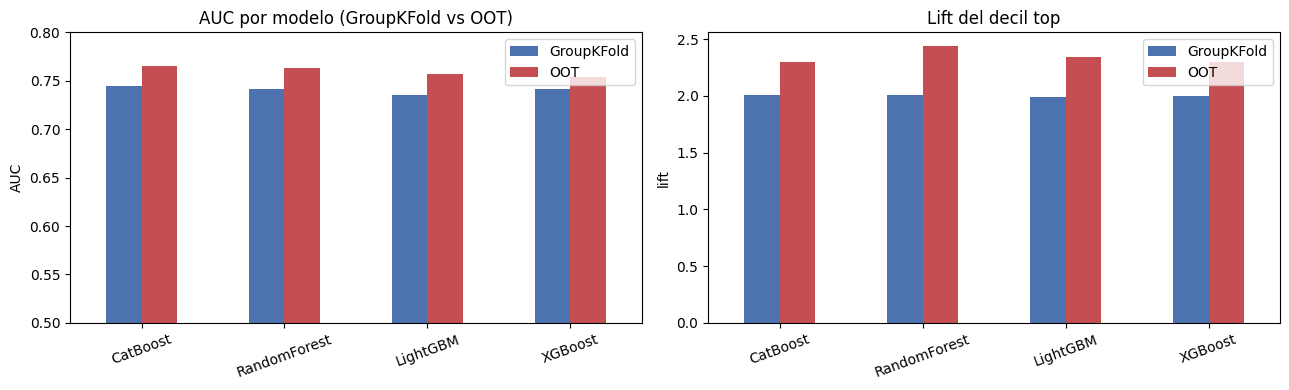

In [5]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
res.loc[tabla.index, ["gkf_AUC", "oot_AUC"]].plot.bar(ax=ax[0], color=["#4c72b0", "#c44e52"])
ax[0].set_title("AUC por modelo (GroupKFold vs OOT)"); ax[0].set_ylim(0.5, 0.8)
ax[0].set_ylabel("AUC"); ax[0].tick_params(axis="x", rotation=20); ax[0].legend(["GroupKFold", "OOT"])
res.loc[tabla.index, ["gkf_lift10", "oot_lift10"]].plot.bar(ax=ax[1], color=["#4c72b0", "#c44e52"])
ax[1].set_title("Lift del decil top"); ax[1].set_ylabel("lift")
ax[1].tick_params(axis="x", rotation=20); ax[1].legend(["GroupKFold", "OOT"])
plt.tight_layout(); plt.show()

## 4 · Síntesis

| Modelo | AUC GroupKFold | AUC OOT | std/mes | F1@.5 | Lift decil |
|---|---|---|---|---|---|
| **CatBoost** | **0.7437** | **0.7659** | 0.021 | 0.542 | 2.39 |
| RandomForest | 0.7410 | 0.7609 | 0.029 | 0.542 | 2.15 |
| XGBoost | 0.7409 | 0.7559 | 0.024 | 0.532 | 2.44 |
| LightGBM | 0.7344 | 0.7482 | 0.019 | 0.522 | 2.34 |

- **Mejor modelo: CatBoost** — gana en AUC por ambos protocolos (OOT 0.766,
  GroupKFold 0.744) con buena estabilidad temporal (std 0.021).
- **Diferencias chicas entre algoritmos** (~1-2pp): el **techo de señal** acota a
  todos por igual; ninguno supera ~0.77.
- XGBoost tiene el mejor lift de decil (2.44×) pero menor AUC; RandomForest es
  segundo pero el más inestable (std 0.029); LightGBM quedó último sin tunear.

**Decisión:** llevar **CatBoost** al tuning de hiperparámetros.

**Próximo paso:** tuning del ganador (Optuna) + evaluación final con SHAP en
`06_evaluation`.